In [3]:
# Assignment Module 5
# --- Q2. Neural Network Fundamentals and Training Behavior Analysis — Graded Assessment ---

In [4]:
!mkdir ../data
# Now upload the datasets provided

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
print("--- Task 1: Data Loading and Basic Exploration ---\n")

df = pd.read_csv('../data/customer_churn_nn.csv')

# Basic Exploration
print(f"Dataset Shape(Rows and Columns): {df.shape}")
print(f"\nData Types: \n{df.dtypes}")
print(f"\nMissing Values:\n{df.isnull().sum()}")
print("\nStatistical Summary:")
display(df.describe())
print("\nFirst Five Rows:")
display(df.head())


--- Task 1: Data Loading and Basic Exploration ---

Dataset Shape(Rows and Columns): (2000, 17)

Data Types: 
customer_id                      object
region                           object
plan_type                        object
contract_type                    object
payment_method                   object
tenure_months                     int64
monthly_charges_inr             float64
avg_login_days_per_month          int64
support_tickets_last_90_days      int64
payment_delay_days                int64
data_usage_gb                   float64
satisfaction_score              float64
last_complaint_days_ago           int64
discount_percent                  int64
autopay_enabled                   int64
referral_count                    int64
churn                             int64
dtype: object

Missing Values:
customer_id                     0
region                          0
plan_type                       0
contract_type                   0
payment_method                  0
tenure_mo

,tenure_months,monthly_charges_inr,avg_login_days_per_month,support_tickets_last_90_days,payment_delay_days,data_usage_gb,satisfaction_score,last_complaint_days_ago,discount_percent,autopay_enabled,referral_count,churn
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,25.362000,766.487295,18.099000,1.953000,3.555000,90.007625,6.87395,46.616500,8.255000,0.597500,0.918000,0.015500
std,14.128651,393.420070,5.400628,1.463852,3.885682,53.215719,1.52428,55.065775,7.553708,0.490524,1.041546,0.123561
min,1.000000,255.450000,0.000000,0.000000,0.000000,0.500000,1.00000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,15.000000,427.782500,15.000000,1.000000,1.000000,51.777500,5.87500,6.000000,0.000000,0.000000,0.000000,0.000000
50%,23.000000,688.355000,18.000000,2.000000,2.000000,80.245000,6.80000,28.500000,5.000000,1.000000,1.000000,0.000000
75%,33.000000,1007.372500,22.000000,3.000000,5.000000,119.097500,8.00000,68.000000,15.000000,1.000000,1.000000,0.000000
max,72.000000,2156.520000,30.000000,8.000000,31.000000,265.510000,10.00000,424.000000,20.000000,1.000000,7.000000,1.000000



First Five Rows:


,customer_id,region,plan_type,contract_type,payment_method,tenure_months,monthly_charges_inr,avg_login_days_per_month,support_tickets_last_90_days,payment_delay_days,data_usage_gb,satisfaction_score,last_complaint_days_ago,discount_percent,autopay_enabled,referral_count,churn
0,CUST0001,South,Standard,Month-to-month,Debit Card,30,687.40,13,0,0,87.97,8.0,67,0,0,0,0
1,CUST0002,West,Premium,Month-to-month,Wallet,15,1029.74,22,3,1,82.17,5.7,69,0,0,0,0
2,CUST0003,Central,Standard,Month-to-month,Credit Card,72,732.07,13,0,11,89.39,6.4,63,10,0,0,0
3,CUST0004,West,Premium,Month-to-month,Credit Card,22,959.51,19,2,3,139.73,7.2,130,5,0,0,0
4,CUST0005,North,Premium,Month-to-month,Net Banking,11,890.20,18,2,6,156.43,5.8,0,5,1,2,0


--- Task 2: Data Preprocessing & Train-Test Split ---

--- 1. Class Distribution ---
churn
0    1969
1      31
Name: count, dtype: int64

churn
0    0.9845
1    0.0155
Name: proportion, dtype: float64



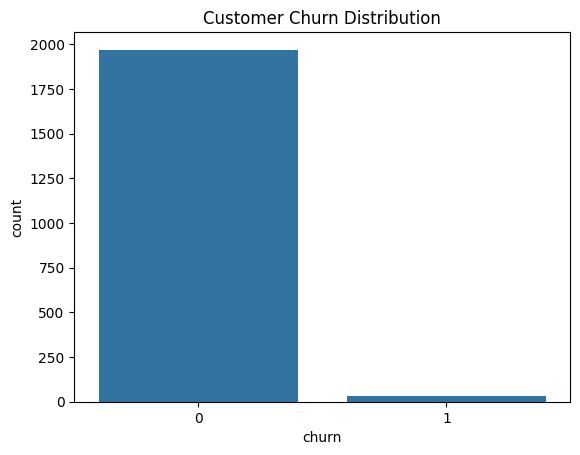

In [23]:
print("--- Task 2: Data Preprocessing & Train-Test Split ---\n")

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.utils import class_weight


# --- 1. Explore Class Distribution ---
print("--- 1. Class Distribution ---")
print(df['churn'].value_counts())
print()
# Normalized
print(df['churn'].value_counts(normalize=True))
print()
sns.countplot(x='churn', data=df)
plt.title('Customer Churn Distribution')
plt.savefig("Customer_Churn_Dist.png")
plt.show()

# --- 2. Encode Categorical Features & 3. Scale Numerical Features ---
# First, drop the identifier as it's not a predictive feature
X = df.drop(columns=['customer_id', 'churn'])

# Target Variable
y = df['churn']

# Identify column types
categorical_features = ['region', 'plan_type', 'contract_type', 'payment_method']
for col in categorical_features:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])

numerical_features = X

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# --- 3. Train/Test Split ---
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

weights = class_weight.compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights_dict = {i: weights[i] for i in range(len(weights))}



In [27]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam, RMSprop

print("--- Task 3 & 4: Neural Network Model Creation, Training & Evaluation ---")

# --- 1. Build Feed-Forward Neural Network ---
def build_model(learning_rate=0.001, dropout_rate=0.2):
    model = Sequential([
        Dense(32, activation='relu', input_shape=(X_train.shape[1],)),
        Dropout(dropout_rate),
        Dense(16, activation='relu'),
        Dropout(dropout_rate),
        Dense(1, activation='sigmoid') # Sigmoid for binary classification
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model


# --- 2. Compare Hyperparameter Configurations ---
# Configuration A: Standard model
print("\n--- Training Configuration A (Baseline) ---")
model_a = build_model()
history = model_a.fit(X_train, y_train, epochs=50, batch_size=32, verbose=0, validation_split=0.2)
# Configuration B: Large Batch Size model
print("\n--- Training Configuration B (Large Batch Size) ---")
model_b = build_model()
model_b.fit(X_train, y_train, batch_size=128, verbose=0)

# Configuration B: Weighted model (Handling class imbalance)
# This is a critical configuration change since the data is 98% class 0
print("\n--- Training Configuration C (Weighted for Imbalance) ---")
weights = class_weight.compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights_dict = dict(enumerate(weights))

model_c = build_model(learning_rate=0.0005, dropout_rate=0.3) # Slower learning, higher dropout
model_c.fit(X_train, y_train, epochs=50, batch_size=32, class_weight=class_weights_dict, verbose=0)


print("\n--- Task 5: Hyperparameter Experimentation ---\n")
# --- 3. Report Performance (Accuracy, Confusion Matrix) ---
def evaluate_model(model, X_test, y_test, name):
    y_pred = (model.predict(X_test) > 0.5).astype(int)

    # Calculate metrics for the comparison table
    acc = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred, output_dict=True)

    # We focus on '1' (Churn) since it's the minority class we care about
    precision_1 = report['1']['precision']
    recall_1 = report['1']['recall']
    f1_1 = report['1']['f1-score']

    print(f"\n{'='*20} Performance Results: {name} {'='*20}")
    print(f"Accuracy: {acc:.4f}")
    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))
    return {
        "Configuration": name,
        "Accuracy": acc,
        "Churn Precision": precision_1,
        "Churn Recall": recall_1,
        "Churn F1-Score": f1_1
    }

results_a = evaluate_model(model_a, X_test, y_test, "Baseline Model (Unweighted)")
results_b = evaluate_model(model_b, X_test, y_test, "Large Batch Size Model")
results_c = evaluate_model(model_c, X_test, y_test, "Weighted & Hyperparameter-Adjusted Model")

--- Task 3 & 4: Neural Network Model Creation, Training & Evaluation ---

--- Training Configuration A (Baseline) ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



--- Training Configuration B (Large Batch Size) ---

--- Training Configuration C (Weighted for Imbalance) ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



--- Task 5: Hyperparameter Experimentation ---

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step

==================== Performance Results: Baseline Model (Unweighted) ====================
Accuracy: 0.9825

Confusion Matrix:
[[392   1]
 [  6   1]]

Classification Report:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       393
           1       0.50      0.14      0.22         7

    accuracy                           0.98       400
   macro avg       0.74      0.57      0.61       400
weighted avg       0.98      0.98      0.98       400

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step

==================== Performance Results: Large Batch Size Model ====================
Accuracy: 0.7750

Confusion Matrix:
[[308  85]
 [  5   2]]

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.78      0.87       393
           1       0.02      0.29      0.04         7

    accuracy                         

--- Task 6: Comparison Table ---

==================== Comparison Table: ====================
                           Configuration  Accuracy  Churn Precision  Churn Recall  Churn F1-Score
             Baseline Model (Unweighted)    0.9825         0.500000      0.142857        0.222222
                  Large Batch Size Model    0.7750         0.022989      0.285714        0.042553
Weighted & Hyperparameter-Adjusted Model    0.8875         0.047619      0.285714        0.081633


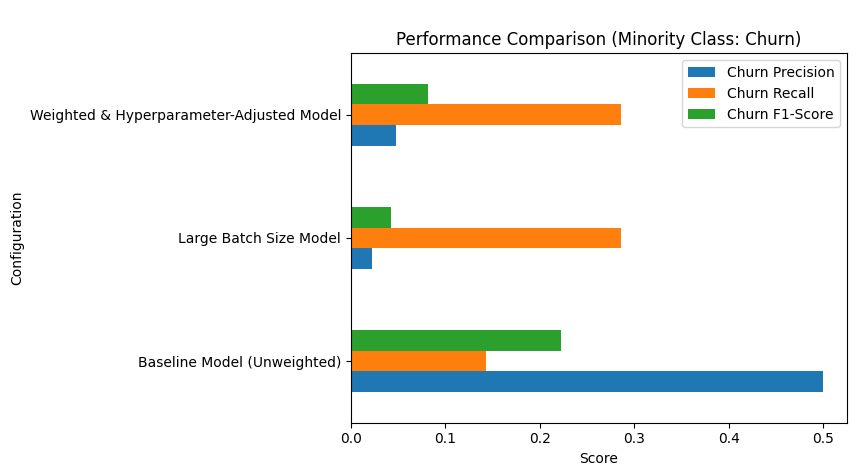

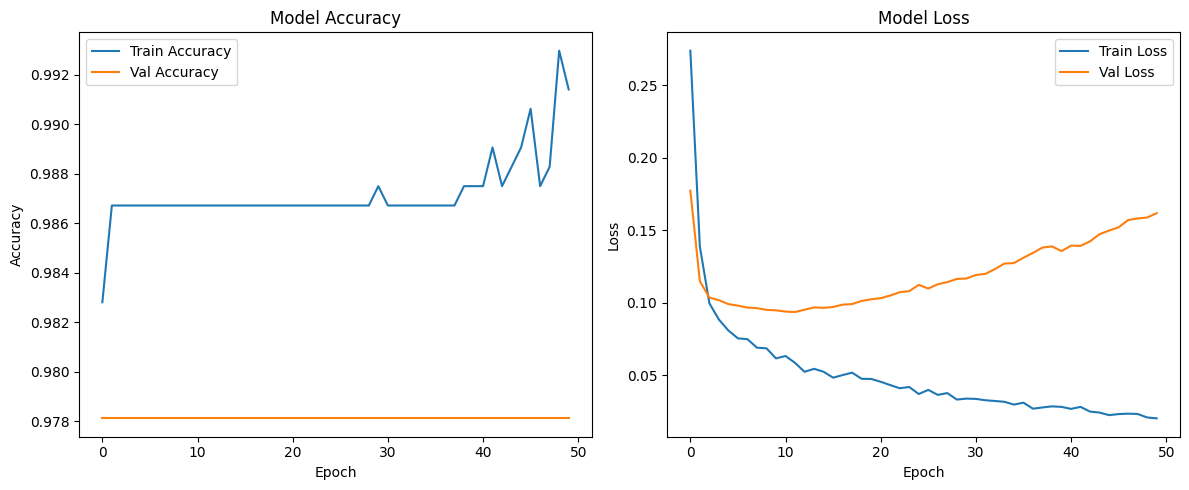

In [28]:
print("--- Task 6: Comparison Table ---")

# --- 1. Create Comparison Table ---
comparison_df = pd.DataFrame([results_a, results_b, results_c])
comparison_df.to_csv('model_comparison_table.csv', index=False)
print(f"\n{'='*20} Comparison Table: {'='*20}")
print(comparison_df.to_string(index=False))

# Visualize the comparison table
comparison_df.set_index('Configuration')[['Churn Precision', 'Churn Recall', 'Churn F1-Score']].plot(kind='barh')
plt.title('\nPerformance Comparison (Minority Class: Churn)')
plt.ylabel('Configuration')
plt.xlabel('Score')
plt.xticks(rotation=0)
plt.savefig("Performance_Comparison(Minority).png")
plt.tight_layout
plt.show()
print()

# --- 2. Visualization of Standard Model---
# Plot Training History
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.savefig("evaluation_output1.png")

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.savefig("Evaluation_output2.png")
plt.show()

### Task 6: Final Reflection

1. What role do weights and biases play in the model?\
Weights determine the importance of input features. Biases help shift activation values and improve learning flexibility. Together, they allow the neural network to learn patterns from data.

2. Why Activation Functions Are required?\
Activation functions introduce non-linearity. Without them, neural networks behave like simple linear models and cannot learn complex relationships.\
**Examples:**
ReLU,
Sigmoid,
Tanh

3. What happens when learning rate is too high or too low?\
**Learning Rate Too High**\
-Training becomes unstable\
-Loss may oscillate\
-Model may never converge\
**Learning Rate Too Low**\
-Training becomes very slow\
-Model may get stuck\
-Requires many epochs

4. Did your model show signs of underfitting or overfitting? Explain.\
**Underfitting Occurs when:**\
-Model is too simple\
-Training accuracy is low\
-Model cannot learn patterns\
**Overfitting Occurs when:**\
-Training accuracy is very high\
-Testing accuracy is low\
-Model memorizes training data

**Signs of overfitting:**
Validation loss increases while training loss decreases